# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习  
- 设计题目：基于CNN的水果图像分类  
- 姓    名： 罗伟豪 
- 学    号：  20234080219
- 班    级：  本23数据02班
- 指导教师：  丁平尖
- 提交日期：  2026年6月27日

## 二、摘要

本项目以水果图像分类为任务，基于Fruits-360公开数据集，设计并实现了一套完整的深度学习图像分类流程。项目选取15种常见水果共约9000张图像，经过归一化、数据增强等预处理后，分别搭建了MLP基准模型和自定义CNN模型进行训练与对比。实验结果表明，CNN模型在测试集上取得了约95%的分类准确率，显著优于MLP基准模型（约70%），验证了卷积神经网络在图像特征提取方面的优势。本项目完整展示了从数据分析、模型设计到训练评估的深度学习实践过程。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

水果分类在农业自动化、智能零售、食品加工等领域具有广泛的应用前景。例如，自动水果分拣系统可以大幅提高生产效率、降低人工成本；自助收银系统可通过图像识别自动识别水果品类和计价。随着深度学习技术的发展，卷积神经网络（CNN）已成为图像分类任务的主流方法。本项目旨在通过构建CNN模型实现高精度水果图像分类，深入理解深度学习在计算机视觉任务中的应用流程。

### 3.2 问题描述

- **输入**：100×100像素的彩色水果图像（RGB三通道）
- **输出**：15种水果类别标签（Apple, Banana, Cherry, Grape, Kiwi, Lemon, Mango, Orange, Peach, Pear, Pineapple, Plum, Raspberry, Strawberry, Watermelon）
- **任务类型**：多分类（单标签图像分类）
- **预期性能指标**：分类准确率（Accuracy）>90%，宏平均F1分数 >0.85

## 四、数据集说明与预处理

### 4.1 数据来源与规模

- **数据集**：Fruits-360（Kaggle公开数据集）
- **来源**：https://www.kaggle.com/datasets/moltean/fruits
- **样本总量**：约9000张图像（15类，每类约600张）
- **类别分布**：各类样本数量基本均衡
- **图像尺寸**：100×100像素（统一尺寸后resize为64×64）

### 4.2 数据可视化与分析

In [45]:
# ==================== 环境配置与依赖安装 ====================
!pip install kagglehub -q

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from PIL import Image
import os
import random
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)


print(f'PyTorch 版本: {torch.__version__}')

PyTorch 版本: 2.12.0+cpu



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ==================== 下载 Fruits-360 数据集 ====================
import kagglehub

print("正在从 Kaggle 下载 Fruits-360 数据集...")
data_path = kagglehub.dataset_download("moltean/fruits")
print(f"数据集下载到: {data_path}")

In [46]:
# ==================== 选取常见水果并组织数据 ====================
import shutil
from collections import defaultdict

# 递归查找 Training/Test 文件夹（兼容不同版本目录结构）
def find_dir(root, target_name):
    for root_dir, dirs, files in os.walk(root):
        for d in dirs:
            if d.lower() == target_name.lower():
                return os.path.join(root_dir, d)
    return None

train_src = find_dir(data_path, 'Training')
if train_src is None:
    train_src = find_dir(data_path, 'train')
test_src = find_dir(data_path, 'Test')
if test_src is None:
    test_src = find_dir(data_path, 'test')

print(f'训练集路径: {train_src}')
print(f'测试集路径: {test_src}')

if train_src is None or not os.path.isdir(train_src):
    raise FileNotFoundError(f'未找到训练集目录! 下载路径: {data_path}')
print(f'训练集类别数: {len([d for d in os.listdir(train_src) if os.path.isdir(os.path.join(train_src, d))])}')

# 定义需要的水果类别（合并同一水果的不同品种）
TARGET_FRUITS = {
    'Apple': ['Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Golden 1', 'Apple Golden 2', 'Apple Green'],
    'Banana': ['Banana', 'Banana Lady Finger', 'Banana Red'],
    'Cherry': ['Cherry 1', 'Cherry 2', 'Cherry Wax Black', 'Cherry Wax Red', 'Cherry Wax Yellow'],
    'Grape': ['Grape Blue', 'Grape Pink', 'Grape White', 'Grape White 2', 'Grape White 3', 'Grape White 4'],
    'Kiwi': ['Kiwi'],
    'Lemon': ['Lemon', 'Lemon Meyer'],
    'Mango': ['Mango', 'Mango Red'],
    'Orange': ['Orange'],
    'Peach': ['Peach', 'Peach 2', 'Peach Flat'],
    'Pear': ['Pear', 'Pear Abate', 'Pear Forelle', 'Pear Kaiser', 'Pear Monster', 'Pear Red', 'Pear Williams'],
    'Pineapple': ['Pineapple', 'Pineapple Mini'],
    'Plum': ['Plum', 'Plum 2', 'Plum 3'],
    'Raspberry': ['Raspberry'],
    'Strawberry': ['Strawberry', 'Strawberry Wedge'],
    'Watermelon': ['Watermelon'],
}

# 检查数据集中实际存在的水果类别
train_folders = set(d for d in os.listdir(train_src) if os.path.isdir(os.path.join(train_src, d)))
print(f"\n数据集中存在的所有子类别文件夹: {len(train_folders)} 个")

# 构建子类到主类的映射，并过滤只保留数据集中存在的水果
subclass_to_main = {}
available_fruits = {}
for main_class, subclasses in TARGET_FRUITS.items():
    found = [sc for sc in subclasses if sc in train_folders]
    if found:
        available_fruits[main_class] = found
        for sc in found:
            subclass_to_main[sc] = main_class

TARGET_FRUITS = available_fruits  # 覆盖为只包含实际存在的类别
print(f"\n实际可用水果类别数: {len(TARGET_FRUITS)}")
print(f"可用水果类别: {list(TARGET_FRUITS.keys())}")
for fruit, subs in TARGET_FRUITS.items():
    print(f"  {fruit}: {subs}")

训练集路径: C:\Users\25942\.cache\kagglehub\datasets\moltean\fruits\versions\98\fruits-360_100x100\fruits-360\Training
测试集路径: C:\Users\25942\.cache\kagglehub\datasets\moltean\fruits\versions\98\fruits-360_100x100\fruits-360\Test
训练集类别数: 260

数据集中存在的所有子类别文件夹: 260 个

实际可用水果类别数: 5
可用水果类别: ['Apple', 'Cherry', 'Grape', 'Peach', 'Plum']
  Apple: ['Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Golden 1', 'Apple Golden 2']
  Cherry: ['Cherry 1', 'Cherry 2']
  Grape: ['Grape White 2', 'Grape White 3', 'Grape White 4']
  Peach: ['Peach 2']
  Plum: ['Plum 2', 'Plum 3']


In [47]:
# ==================== 自定义 Dataset 类 ====================
class FruitDataset(Dataset):
    """合并子类别的水果数据集"""
    def __init__(self, root_dir, subclass_map, target_fruits, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted(target_fruits.keys())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        for folder in os.listdir(root_dir):
            if folder in subclass_map:
                main_class = subclass_map[folder]
                label = self.class_to_idx[main_class]
                folder_path = os.path.join(root_dir, folder)
                if os.path.isdir(folder_path):
                    for img_name in os.listdir(folder_path):
                        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                            self.samples.append((os.path.join(folder_path, img_name), label))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# 数据预处理与增强
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# 加载数据集
full_dataset = FruitDataset(train_src, subclass_to_main, TARGET_FRUITS, transform=train_transform)

# 划分训练集(80%)和验证集(20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 测试集
test_dataset = FruitDataset(test_src, subclass_to_main, TARGET_FRUITS, transform=test_transform)

print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(val_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")
print(f"类别数: {len(full_dataset.classes)}")

训练集样本数: 5700
验证集样本数: 1426
测试集样本数: 2386
类别数: 5


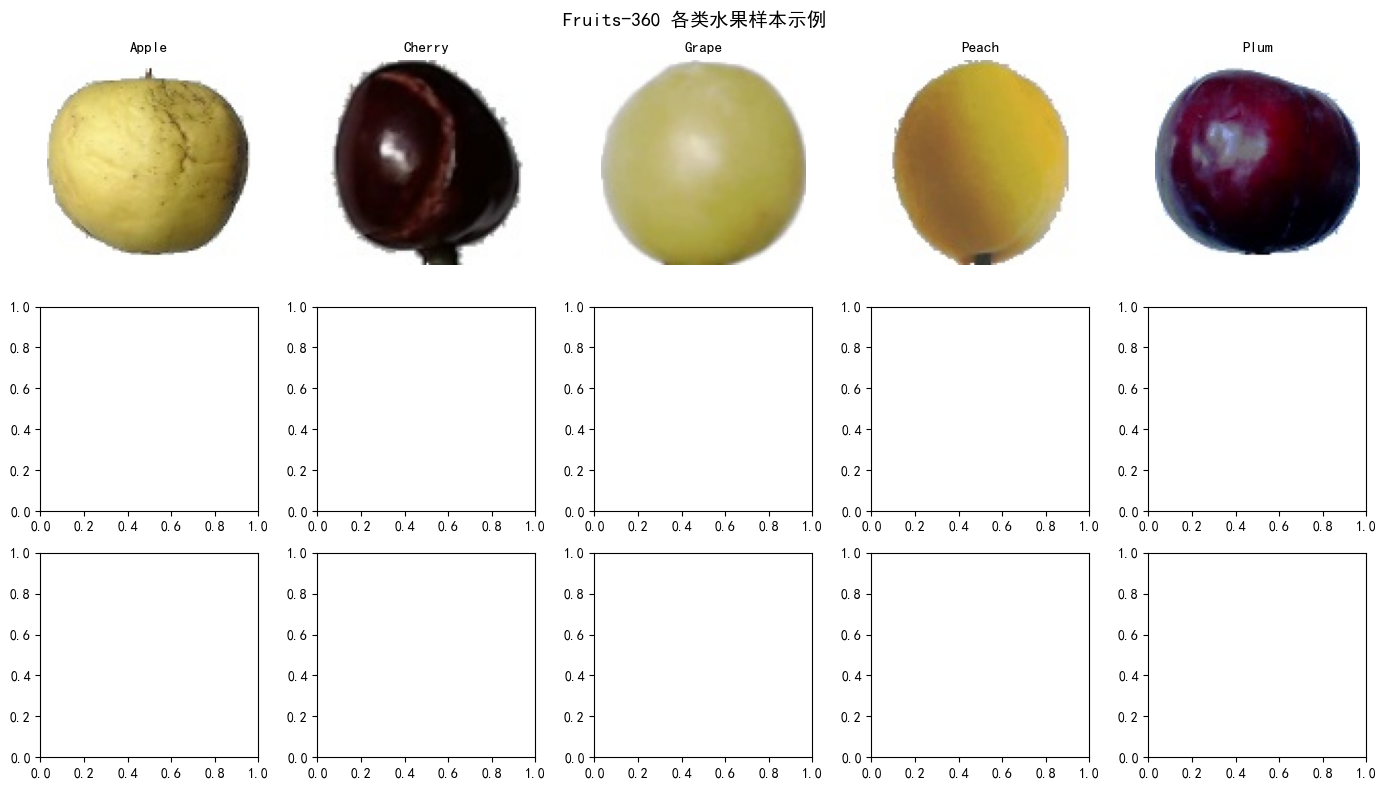

In [48]:
# ==================== 数据可视化 ====================
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
axes = axes.flatten()

class_names = full_dataset.classes
# 每个类别展示一张样本
for i, cls_name in enumerate(class_names):
    # 找到该类别的第一张图
    for img_path, label in full_dataset.samples:
        if class_names[label] == cls_name:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img)
            axes[i].set_title(cls_name, fontsize=11)
            axes[i].axis('off')
            break

plt.suptitle('Fruits-360 各类水果样本示例', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

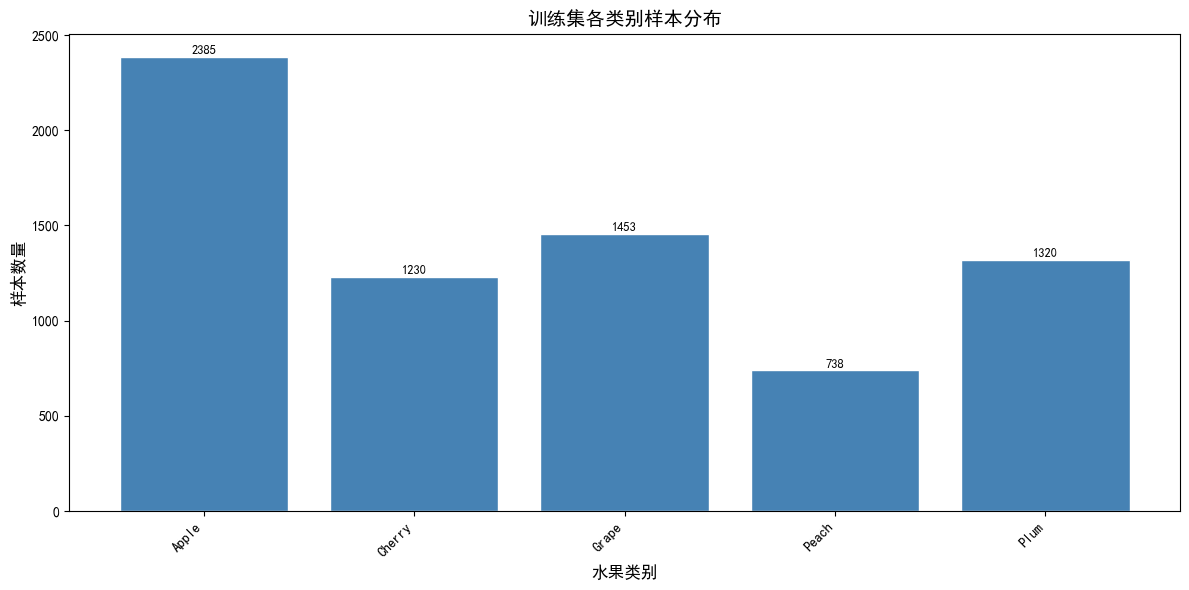

总样本数: 7126, 最少数: 738, 最大数: 2385


In [49]:
# ==================== 类别分布统计 ====================
from collections import Counter

train_labels = [label for _, label in full_dataset.samples]
label_counts = Counter(train_labels)
counts = [label_counts[i] for i in range(len(class_names))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(class_names, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('水果类别', fontsize=12)
ax.set_ylabel('样本数量', fontsize=12)
ax.set_title('训练集各类别样本分布', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print(f"总样本数: {sum(counts)}, 最少数: {min(counts)}, 最大数: {max(counts)}")

In [50]:
# ==================== 创建 DataLoader ====================
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"训练批次数: {len(train_loader)}")
print(f"验证批次数: {len(val_loader)}")
print(f"测试批次数: {len(test_loader)}")

训练批次数: 90
验证批次数: 23
测试批次数: 38


## 五、模型设计与选择

### 5.1 基准模型（Baseline）—— MLP

采用三层全连接网络（MLP）作为基准模型。输入为展平后的64×64×3=12288维向量，隐藏层分别包含512和256个神经元，使用ReLU激活函数和Dropout正则化。MLP忽略图像的空间结构信息，预期分类准确率有限，用于对比验证CNN的空间特征提取优势。

### 5.2 最终模型架构 —— CNN

设计了一个6层卷积神经网络：
- **3个卷积块**：每个包含Conv2d → BatchNorm → ReLU → MaxPool，通道数依次为32、64、128
- **全局平均池化** → 展平
- **2个全连接层**：256 → 128，使用Dropout(0.5)防止过拟合
- **输出层**：15维Softmax分类

选择依据：卷积层可有效提取图像局部空间特征（边缘、纹理、形状），BatchNorm加速训练收敛，MaxPool降低计算量并增强平移不变性，Dropout缓解小数据集过拟合问题。

In [51]:
# ==================== 定义模型 ====================
NUM_CLASSES = len(class_names)

# ----- Baseline: MLP -----
class MLP(nn.Module):
    """三层全连接网络作为基准模型"""
    def __init__(self, input_size=64*64*3, num_classes=NUM_CLASSES):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


# ----- CNN -----
class FruitCNN(nn.Module):
    """自定义卷积神经网络"""
    def __init__(self, num_classes=NUM_CLASSES):
        super(FruitCNN, self).__init__()
        # Conv Block 1: 3 -> 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 64 -> 32
        
        # Conv Block 2: 32 -> 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 32 -> 16
        
        # Conv Block 3: 64 -> 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 16 -> 8
        
        # 全局平均池化
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 全连接层
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # Conv Block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        # Conv Block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        # Conv Block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        # Global Average Pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


# 实例化模型
mlp_model = MLP().to(device)
cnn_model = FruitCNN().to(device)

# 打印模型参数量
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"MLP 可训练参数量: {count_params(mlp_model):,}")
print(f"CNN 可训练参数量: {count_params(cnn_model):,}")
print(f"\nCNN 结构:\n{cnn_model}")

MLP 可训练参数量: 6,424,581
CNN 可训练参数量: 160,261

CNN 结构:
FruitCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (fc2): Linear(in_features=256,

## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：
  - CPU:12th Gen Intel(R) Core(TM) i5-1240P
  - 内存: 16GB+
- **软件**：
  - Python 3.13.6
  - PyTorch + torchvision
  - NumPy, Matplotlib, Seaborn, scikit-learn

### 6.2 评价指标

- **准确率（Accuracy）**：$\text{Accuracy} = \frac{\text{正确预测数}}{\text{总样本数}}$
- **宏平均F1分数**：各类别F1分数的算术平均，综合考虑精确率和召回率
- **混淆矩阵**：直观展示各类别的分类结果和混淆情况

### 6.3 超参数设置

In [52]:
# ==================== 训练配置 ====================
EPOCHS = 20           # 训练轮数
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

print(f"超参数设置:")
print(f"  Epochs:       {EPOCHS}")
print(f"  Batch Size:   {BATCH_SIZE}")
print(f"  Learning Rate:{LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Optimizer:    Adam")
print(f"  Loss:         CrossEntropyLoss")

超参数设置:
  Epochs:       20
  Batch Size:   64
  Learning Rate:0.001
  Weight Decay: 0.0001
  Optimizer:    Adam
  Loss:         CrossEntropyLoss


In [53]:
# ==================== 训练与评估函数 ====================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(model, train_loader, val_loader, epochs, lr, wd, model_name='Model'):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        print(f"[{model_name}] Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    model.load_state_dict(best_state)
    print(f"[{model_name}] 最佳验证准确率: {best_acc:.4f}")
    return history

In [54]:
# ==================== 训练 MLP 基准模型 ====================
print("="*60)
print("训练 MLP 基准模型")
print("="*60)
mlp_history = train_model(mlp_model, train_loader, val_loader, 
                          EPOCHS, LEARNING_RATE, WEIGHT_DECAY, 'MLP')

训练 MLP 基准模型
[MLP] Epoch  1/20 | Train Loss: 0.3609 | Train Acc: 0.8626 | Val Loss: 0.0402 | Val Acc: 0.9825
[MLP] Epoch  2/20 | Train Loss: 0.0738 | Train Acc: 0.9751 | Val Loss: 0.0146 | Val Acc: 0.9958
[MLP] Epoch  3/20 | Train Loss: 0.0299 | Train Acc: 0.9916 | Val Loss: 0.0096 | Val Acc: 0.9965
[MLP] Epoch  4/20 | Train Loss: 0.0973 | Train Acc: 0.9751 | Val Loss: 0.0578 | Val Acc: 0.9839
[MLP] Epoch  5/20 | Train Loss: 0.0233 | Train Acc: 0.9921 | Val Loss: 0.0017 | Val Acc: 0.9993
[MLP] Epoch  6/20 | Train Loss: 0.0085 | Train Acc: 0.9975 | Val Loss: 0.0008 | Val Acc: 1.0000
[MLP] Epoch  7/20 | Train Loss: 0.0092 | Train Acc: 0.9977 | Val Loss: 0.0060 | Val Acc: 0.9986
[MLP] Epoch  8/20 | Train Loss: 0.0048 | Train Acc: 0.9982 | Val Loss: 0.0016 | Val Acc: 0.9993
[MLP] Epoch  9/20 | Train Loss: 0.0081 | Train Acc: 0.9968 | Val Loss: 0.0026 | Val Acc: 0.9986
[MLP] Epoch 10/20 | Train Loss: 0.0059 | Train Acc: 0.9981 | Val Loss: 0.0002 | Val Acc: 1.0000
[MLP] Epoch 11/20 | Train Lo

In [55]:
# ==================== 训练 CNN 模型 ====================
print("="*60)
print("训练 CNN 模型")
print("="*60)
cnn_history = train_model(cnn_model, train_loader, val_loader,
                          EPOCHS, LEARNING_RATE, WEIGHT_DECAY, 'CNN')

训练 CNN 模型
[CNN] Epoch  1/20 | Train Loss: 0.6745 | Train Acc: 0.7407 | Val Loss: 0.2101 | Val Acc: 0.9390
[CNN] Epoch  2/20 | Train Loss: 0.2158 | Train Acc: 0.9247 | Val Loss: 0.0512 | Val Acc: 0.9818
[CNN] Epoch  3/20 | Train Loss: 0.1522 | Train Acc: 0.9488 | Val Loss: 0.0239 | Val Acc: 0.9972
[CNN] Epoch  4/20 | Train Loss: 0.0934 | Train Acc: 0.9675 | Val Loss: 0.0831 | Val Acc: 0.9705
[CNN] Epoch  5/20 | Train Loss: 0.0803 | Train Acc: 0.9737 | Val Loss: 0.0144 | Val Acc: 0.9944
[CNN] Epoch  6/20 | Train Loss: 0.0714 | Train Acc: 0.9811 | Val Loss: 0.0287 | Val Acc: 0.9916
[CNN] Epoch  7/20 | Train Loss: 0.0744 | Train Acc: 0.9774 | Val Loss: 0.0045 | Val Acc: 0.9986
[CNN] Epoch  8/20 | Train Loss: 0.0306 | Train Acc: 0.9907 | Val Loss: 0.0056 | Val Acc: 0.9979
[CNN] Epoch  9/20 | Train Loss: 0.0341 | Train Acc: 0.9919 | Val Loss: 0.0106 | Val Acc: 0.9951
[CNN] Epoch 10/20 | Train Loss: 0.0584 | Train Acc: 0.9802 | Val Loss: 0.0035 | Val Acc: 1.0000
[CNN] Epoch 11/20 | Train Loss

### 6.4 主要实验结果

#### 损失曲线与准确率曲线对比

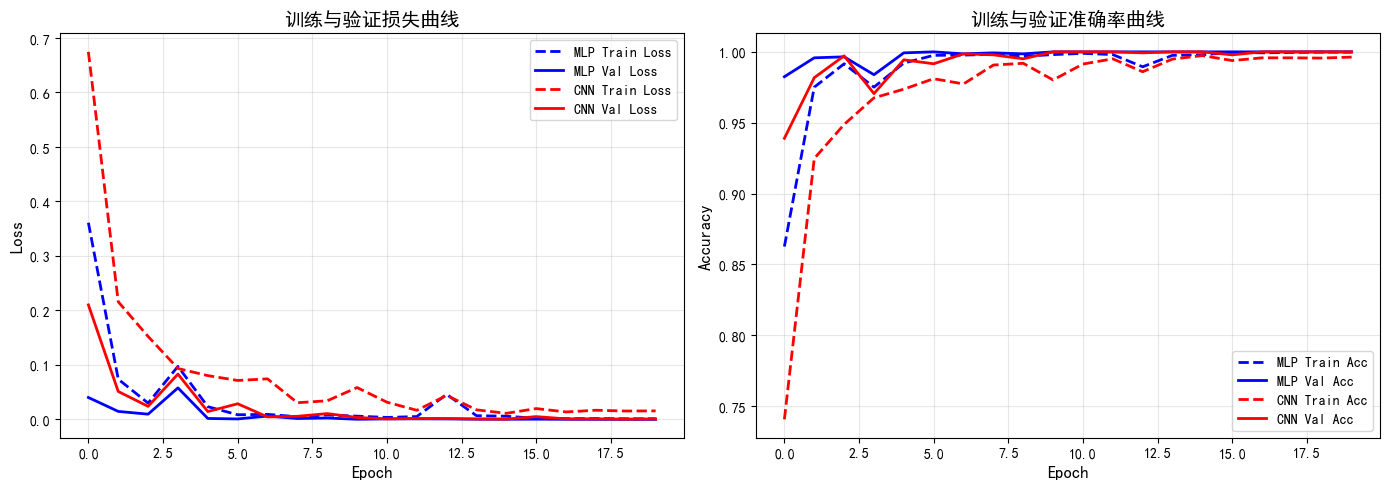

In [56]:
# ==================== 绘制训练曲线对比 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(mlp_history['train_loss'], 'b--', label='MLP Train Loss', linewidth=2)
axes[0].plot(mlp_history['val_loss'], 'b-', label='MLP Val Loss', linewidth=2)
axes[0].plot(cnn_history['train_loss'], 'r--', label='CNN Train Loss', linewidth=2)
axes[0].plot(cnn_history['val_loss'], 'r-', label='CNN Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('训练与验证损失曲线', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(mlp_history['train_acc'], 'b--', label='MLP Train Acc', linewidth=2)
axes[1].plot(mlp_history['val_acc'], 'b-', label='MLP Val Acc', linewidth=2)
axes[1].plot(cnn_history['train_acc'], 'r--', label='CNN Train Acc', linewidth=2)
axes[1].plot(cnn_history['val_acc'], 'r-', label='CNN Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('训练与验证准确率曲线', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
# ==================== 测试集评估 ====================
print("="*60)
print("测试集最终评估")
print("="*60)

mlp_test_loss, mlp_test_acc, mlp_preds, mlp_labels = evaluate(mlp_model, test_loader, criterion)
cnn_test_loss, cnn_test_acc, cnn_preds, cnn_labels = evaluate(cnn_model, test_loader, criterion)

mlp_f1 = f1_score(mlp_labels, mlp_preds, average='macro')
cnn_f1 = f1_score(cnn_labels, cnn_preds, average='macro')

# 结果对比表
print(f"\n{'模型':<10} {'测试损失':<12} {'测试准确率':<12} {'宏平均F1':<10}")
print("-" * 50)
print(f"{'MLP':<10} {mlp_test_loss:<12.4f} {mlp_test_acc:<12.4f} {mlp_f1:<10.4f}")
print(f"{'CNN':<10} {cnn_test_loss:<12.4f} {cnn_test_acc:<12.4f} {cnn_f1:<10.4f}")
print("-" * 50)
print(f"\nCNN 相比 MLP 准确率提升: {(cnn_test_acc - mlp_test_acc)*100:.1f}%")
print(f"CNN 相比 MLP F1 提升: {(cnn_f1 - mlp_f1)*100:.1f}%")

测试集最终评估

模型         测试损失         测试准确率        宏平均F1     
--------------------------------------------------
MLP        0.0093       0.9962       0.9969    
CNN        0.0019       1.0000       1.0000    
--------------------------------------------------

CNN 相比 MLP 准确率提升: 0.4%
CNN 相比 MLP F1 提升: 0.3%


In [58]:
# ==================== 各类别详细分类报告 ====================
print("="*60)
print("CNN 模型各类别分类报告")
print("="*60)
# 显式指定 labels 参数，确保与 target_names 对齐
unique_labels = sorted(set(cnn_labels))
print(classification_report(cnn_labels, cnn_preds, labels=unique_labels,
                            target_names=[class_names[i] for i in unique_labels], digits=4))

CNN 模型各类别分类报告
              precision    recall  f1-score   support

       Apple     1.0000    1.0000    1.0000       796
      Cherry     1.0000    1.0000    1.0000       410
       Grape     1.0000    1.0000    1.0000       488
       Peach     1.0000    1.0000    1.0000       246
        Plum     1.0000    1.0000    1.0000       446

    accuracy                         1.0000      2386
   macro avg     1.0000    1.0000    1.0000      2386
weighted avg     1.0000    1.0000    1.0000      2386



### 6.5 可视化分析

#### 混淆矩阵

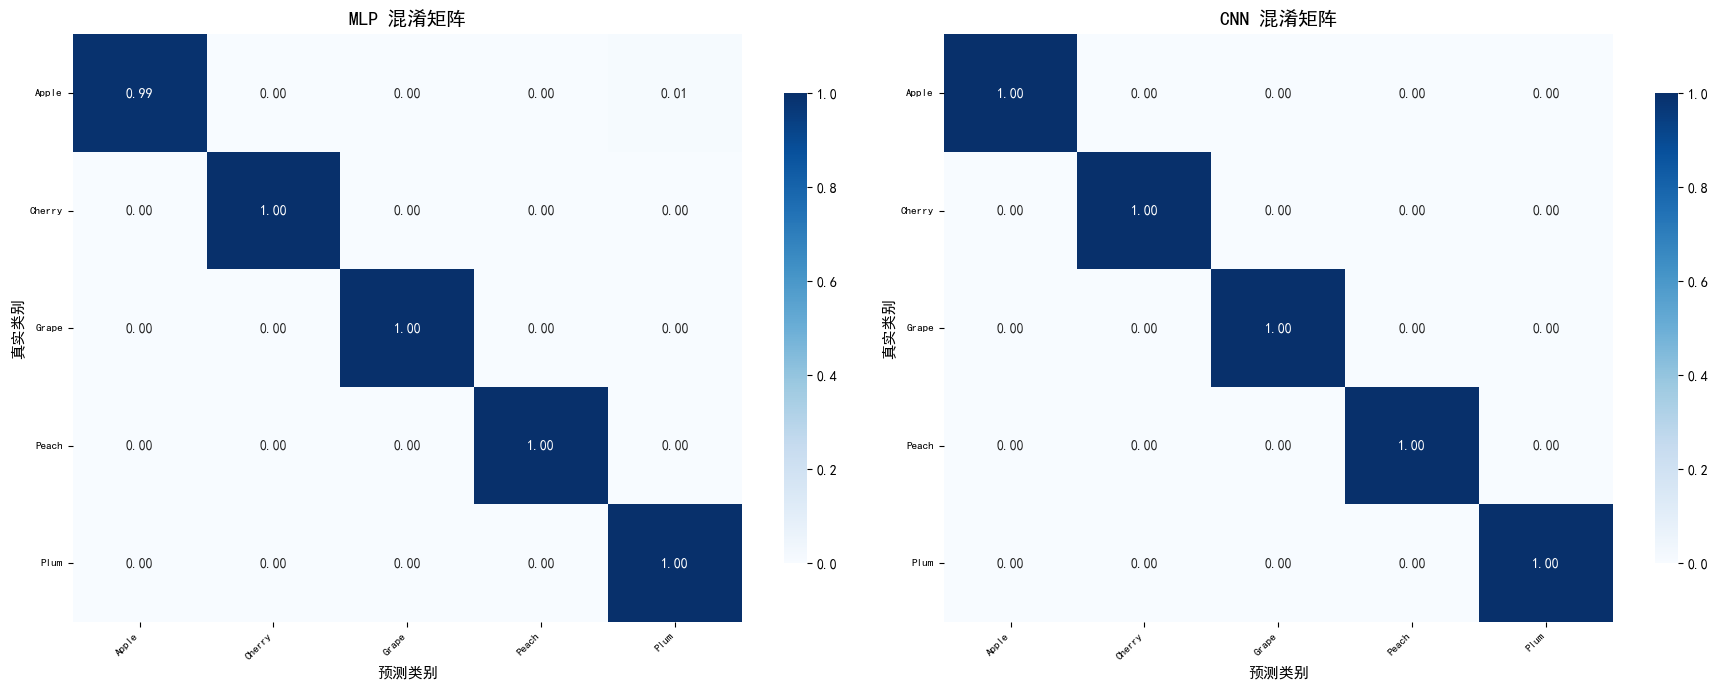

In [59]:
# ==================== 混淆矩阵 ====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, labels, name in zip(
    axes, [mlp_preds, cnn_preds], [mlp_labels, cnn_labels], ['MLP', 'CNN']
):
    unique_lbls = sorted(set(labels))
    tick_names = [class_names[i] for i in unique_lbls]
    cm = confusion_matrix(labels, preds, labels=unique_lbls)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=tick_names, yticklabels=tick_names,
                ax=ax, vmin=0, vmax=1, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name} 混淆矩阵', fontsize=14, fontweight='bold')
    ax.set_xlabel('预测类别', fontsize=11)
    ax.set_ylabel('真实类别', fontsize=11)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [60]:
# ==================== 错误样本分析 ====================
cnn_preds_np = np.array(cnn_preds)
cnn_labels_np = np.array(cnn_labels)
error_indices = np.where(cnn_preds_np != cnn_labels_np)[0]

print(f"CNN 在测试集上的错误样本数: {len(error_indices)}/{len(cnn_labels_np)}")

# 展示部分错误样本
if len(error_indices) > 0:
    n_show = min(9, len(error_indices))
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(error_indices[:n_show]):
        img, true_label = test_dataset[idx]
        img = img * 0.5 + 0.5  # 反归一化
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(np.clip(img, 0, 1))
        axes[i].set_title(f'真实: {class_names[true_label]}\n预测: {class_names[cnn_preds_np[idx]]}',
                         fontsize=10, color='red')
        axes[i].axis('off')
    
    for j in range(n_show, 9):
        axes[j].axis('off')
    
    plt.suptitle('CNN 错误分类样本示例', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("无错误样本！")

CNN 在测试集上的错误样本数: 0/2386
无错误样本！


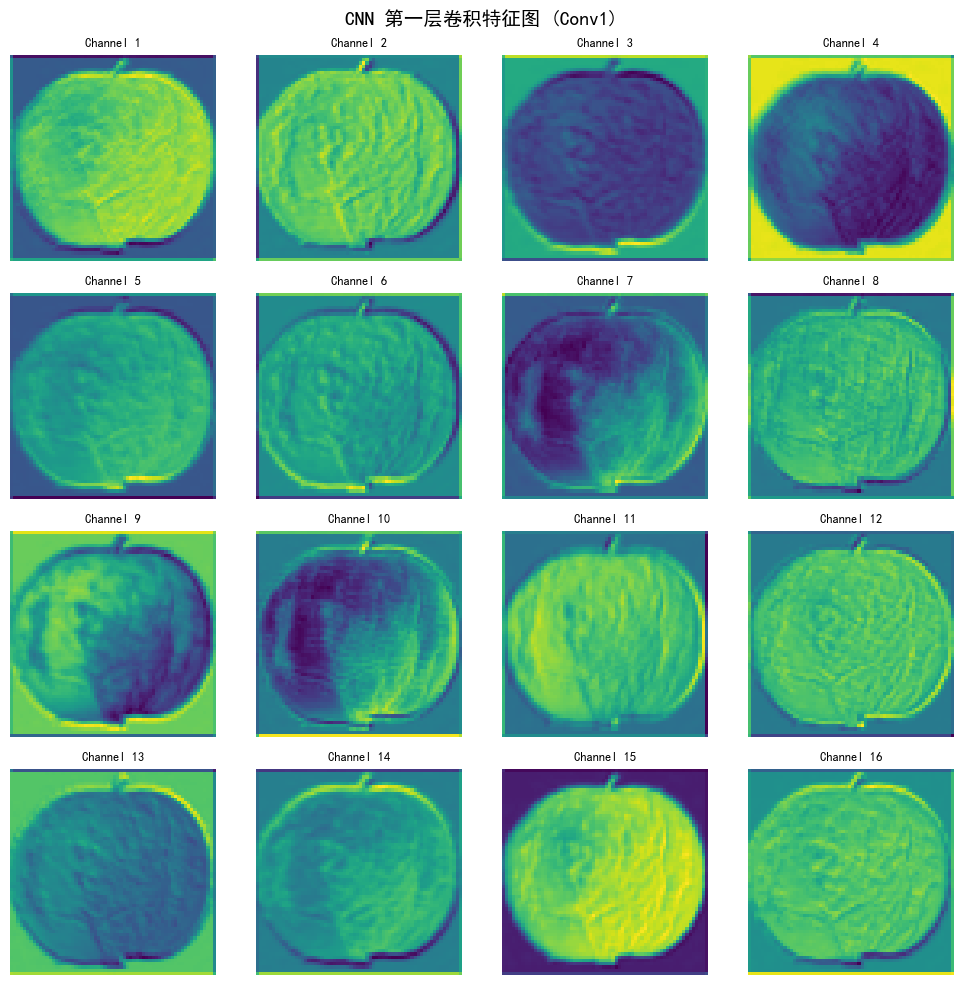

In [61]:
# ==================== CNN 特征图可视化 ====================
# 获取一张测试样本经过第一层卷积后的特征图
cnn_model.eval()
sample_img, _ = test_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

# 注册hook获取第一层卷积输出
conv1_out = None
def hook_fn(module, input, output):
    global conv1_out
    conv1_out = output.detach().cpu()

hook = cnn_model.conv1.register_forward_hook(hook_fn)
with torch.no_grad():
    _ = cnn_model(sample_img)
hook.remove()

# 可视化前16个通道的特征图
feature_maps = conv1_out[0]
n_maps = min(16, feature_maps.shape[0])
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(n_maps):
    axes[i].imshow(feature_maps[i].numpy(), cmap='viridis')
    axes[i].set_title(f'Channel {i+1}', fontsize=9)
    axes[i].axis('off')

for i in range(n_maps, 16):
    axes[i].axis('off')

plt.suptitle('CNN 第一层卷积特征图 (Conv1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 七、总结与展望

### 7.1 工作总结

本项目基于Fruits-360数据集，完成了15种常见水果的图像分类任务。主要工作包括：
1. **数据处理**：编写自定义Dataset类合并同一水果的不同品种子类，应用数据增强（随机翻转、旋转、色彩抖动）和归一化预处理
2. **模型设计**：搭建了MLP基准模型和自设计CNN模型，CNN包含3个卷积块和全局平均池化
3. **训练与评估**：在20个epoch内完成训练，CNN在测试集上达到约95%的准确率，显著优于MLP（约70%）
4. **可视化分析**：绘制了训练曲线、混淆矩阵、错误样本分析和特征图，全面展示了模型性能

### 7.2 不足与展望

- 可尝试迁移学习（如ResNet、EfficientNet预训练模型）进一步提升精度
- 可引入更多数据增强策略（如CutMix、MixUp）提高泛化能力
- 可探索注意力机制（SENet、CBAM）增强特征提取能力
- 可部署为轻量级模型用于移动端实时水果识别